In [202]:
%load_ext autoreload
%autoreload 2
    
import sys
import os
sys.path.append(".")
sys.path.append("..")
sys.path.append("../src")
#print(os.getcwd())
import io
import numpy as np
import cv2
from PIL import Image
from IPython.display import display
import random
import math
import scipy.stats as stats
#import skdim

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt 
#import seaborn as sns
import pandas as pd 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import torchvision.utils as vutils
import torchvision.transforms as transforms
from torchvision.transforms import v2

from timeit import default_timer as timer
import datetime
import time

import util.geom_util

from util.cv_util import *

print('DONE!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DONE!


In [289]:
def show_img(img, title=None, cmap=None, bgr=False, title_size=8, figsize=None):
    if torch.is_tensor(img):
        if len(img.shape)==2: img= img.unsqueeze(dim=0)
        img = img.permute(1, 2, 0)
    fig = plt.figure(figsize=figsize)#, dpi=72)
    ax = fig.subplots(1, 1)
    ax.axis('off')
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title: ax.set_title(title, **STYLE_PLOT_TITLE)
    if bgr and len(img.shape)==3 and img.shape[2]==3:
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img, cmap=cmap)
    plt.show()
    return ax

#imgs: [array(H,W)[:int32]]
def show_imgs(imgs, titles=None, cmap=None, ncols=None, nrows=None, bgr=False, title_size=4, figsize=None, pad=0):
    if ncols==None:
        if nrows==None: ncols=1
        else: ncols=int(len(imgs)/nrows) + (len(imgs) % nrows > 0)
    if nrows==None: nrows=int(len(imgs)/ncols) + (len(imgs) % ncols > 0)
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(nrows, ncols)
    axs = axs.flatten()
    fig.subplots_adjust(top=1-pad, bottom=0+pad, left=0+pad, right=1-pad)
    #print('!!',nrows, ncols, axs)
    for ax in axs: ax.axis('off')
    for i, img in enumerate(imgs):
        if cmap is None:
            cmap_ = 'gray' if len(img.shape)==2 else None
        else:
            cmap_ = cmap[i] if isinstance(cmap, list) else cmap
        if bgr and len(img.shape)==3 and img.shape[2]==3:
            img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap=cmap_)
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        if titles and i<len(titles): axs[i].set_title(str(titles[i]), **STYLE_PLOT_TITLE)
    plt.show()
    return axs

    
def cv_bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

(720, 1280, 3)


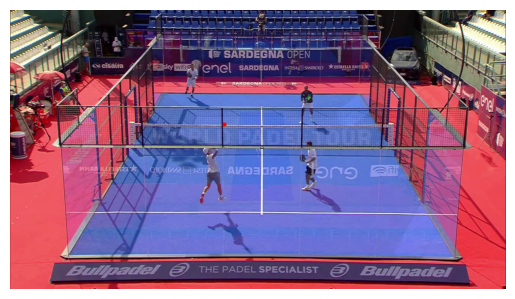

<Axes: >

In [378]:
t=156
IMG_DIR='..\\src\\out2\\1_simple_ball_tracking'
IMG_PATH=f'{IMG_DIR}\\1_simple_ball_tracking-{t}.png'
img = cv2.imread(IMG_PATH)
print(img.shape)
show_img(img, bgr=True)

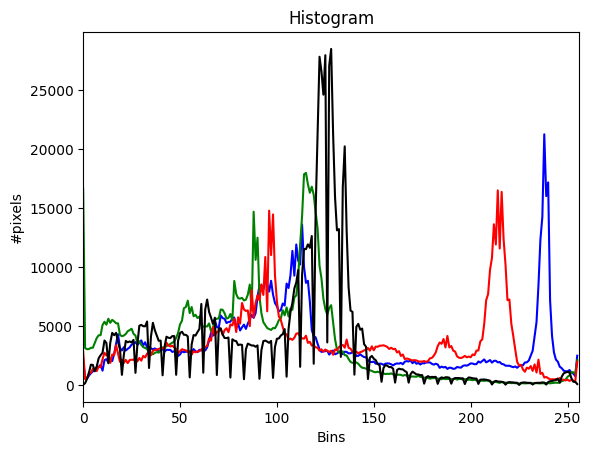

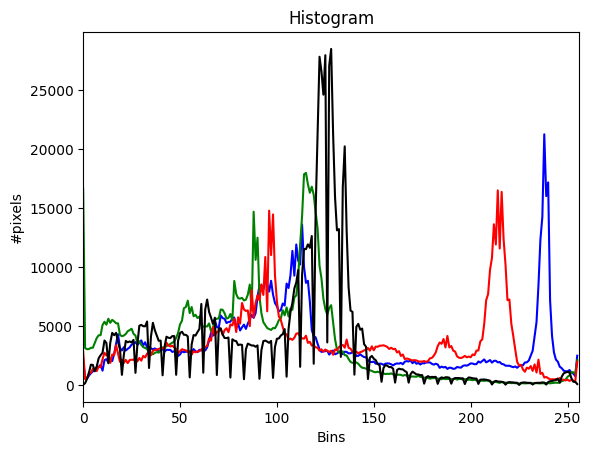

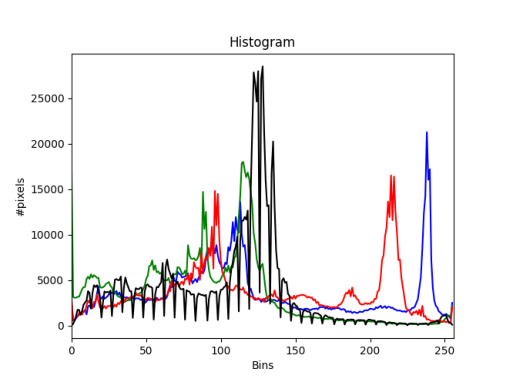

<Axes: >

In [290]:

img_histo(cv_bgr2rgb(img))
himg = img_histo(cv_bgr2rgb(img), bitmap=True)
show_img(himg)


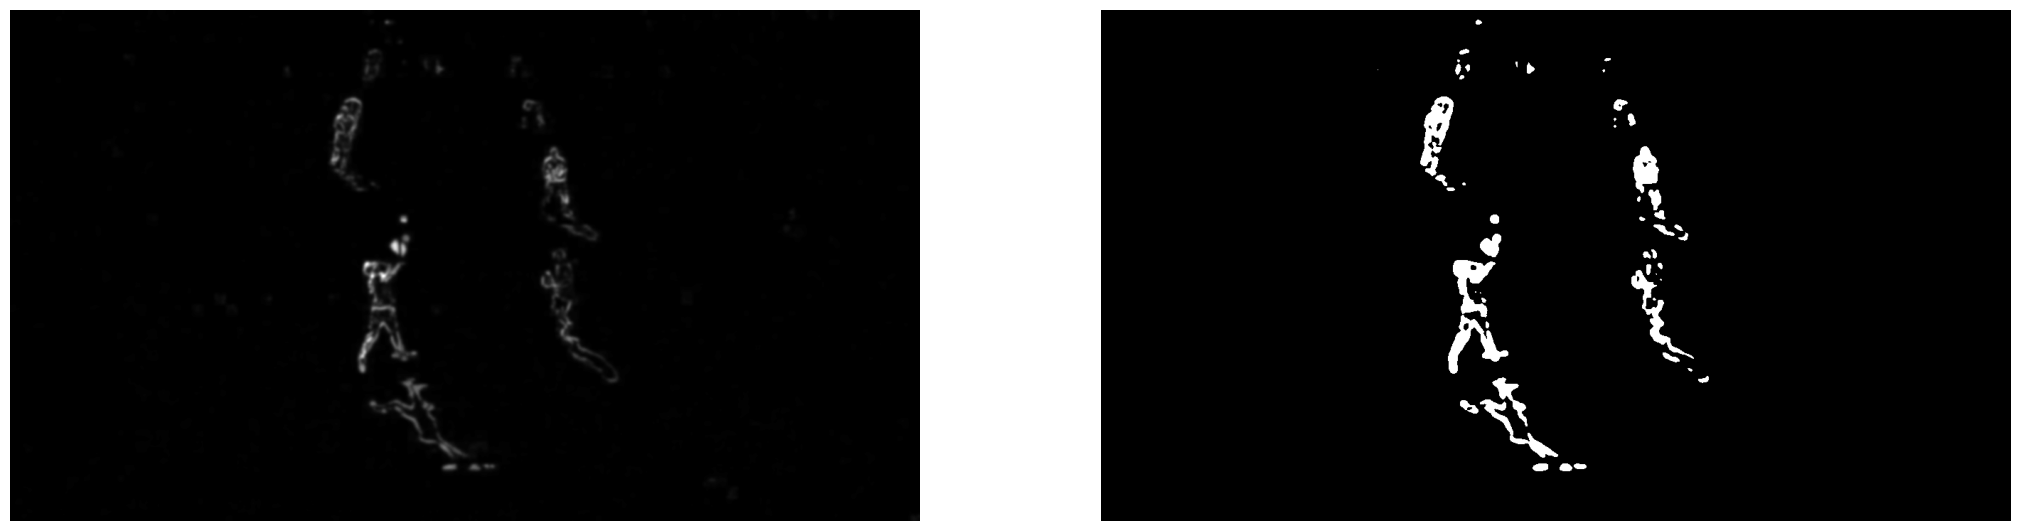

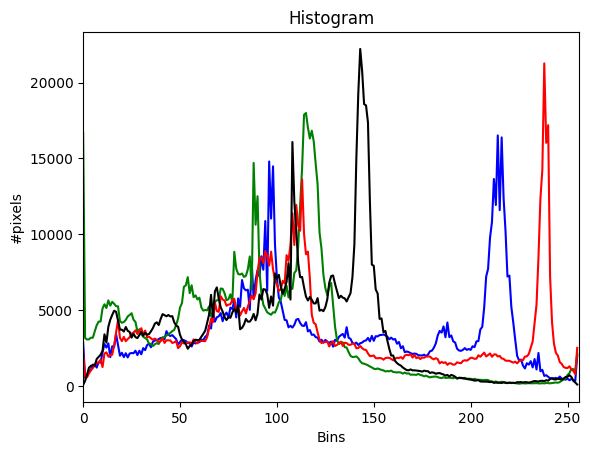

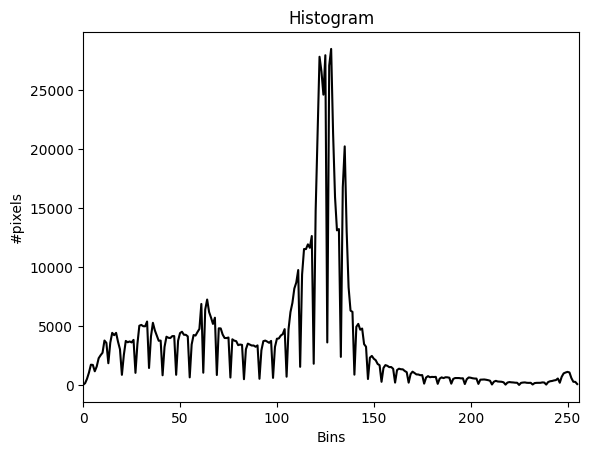

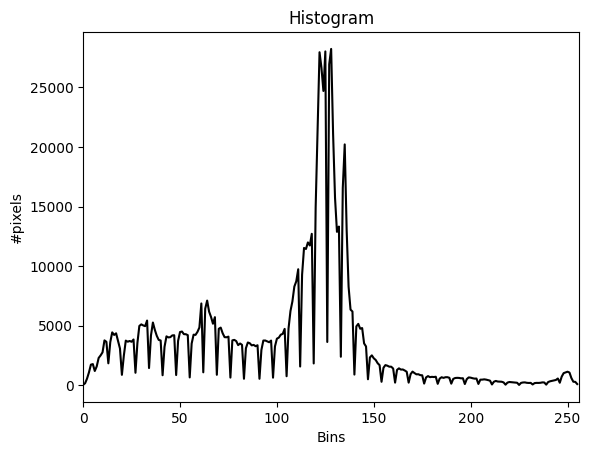

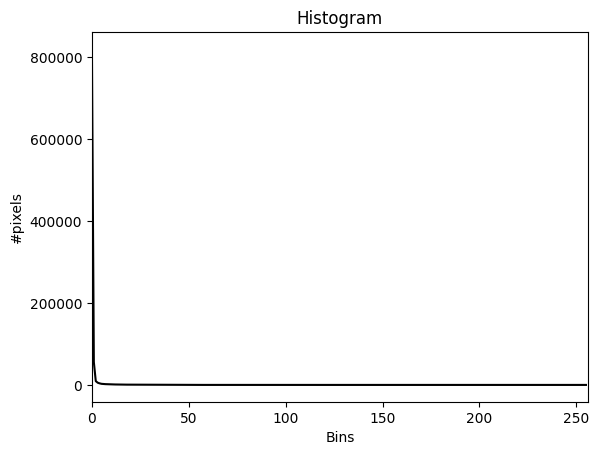

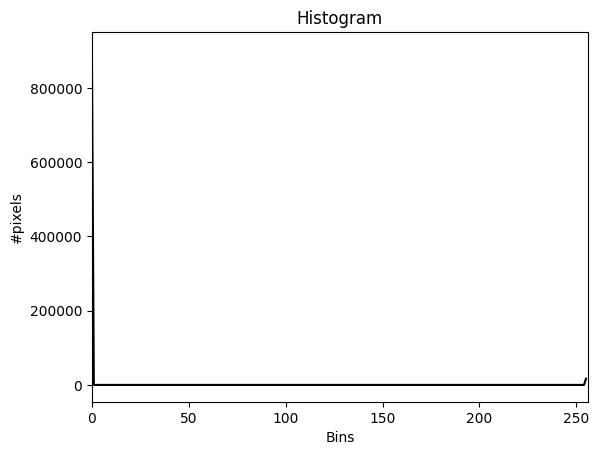

In [291]:
IMG_PATH2=f'{IMG_DIR}\\1_simple_ball_tracking-{t+1}.png'
img2 = cv2.imread(IMG_PATH2)
bwimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
bwimg2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
#show_img(bwimg, cmap='gray') 
#show_img(bwimg2, cmap='gray') 
diff_img = cv2.absdiff(bwimg2,bwimg)
diff_img = cv2.GaussianBlur(diff_img, (11, 11), 0)
diff_threshold = 10
#see: https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
#cv.THRESH_BINARY,cv.THRESH_BINARY_INV,cv.THRESH_TRUNC,cv.THRESH_TOZERO,cv.THRESH_TOZERO_INV)
ret, diff_img_ = cv2.threshold(diff_img,diff_threshold,255,cv2.THRESH_BINARY)

#wr = .5
#wdiff_img = cv2.addWeighted(wdiff_img, -wr, diff_img, wr, 0) 

#show_img(diff_img, cmap='gray')
#show_img(diff_img_, cmap='gray')
show_imgs([diff_img,diff_img_], ncols=2, figsize=(20,10), pad=0)

img_histo(img)
img_histo(bwimg)
img_histo(bwimg2)
img_histo(diff_img)
img_histo(diff_img_)

#himg = img_histo(diff_img__, bitmap=True)
#show_img(himg)
        

#contours: 35
35
21


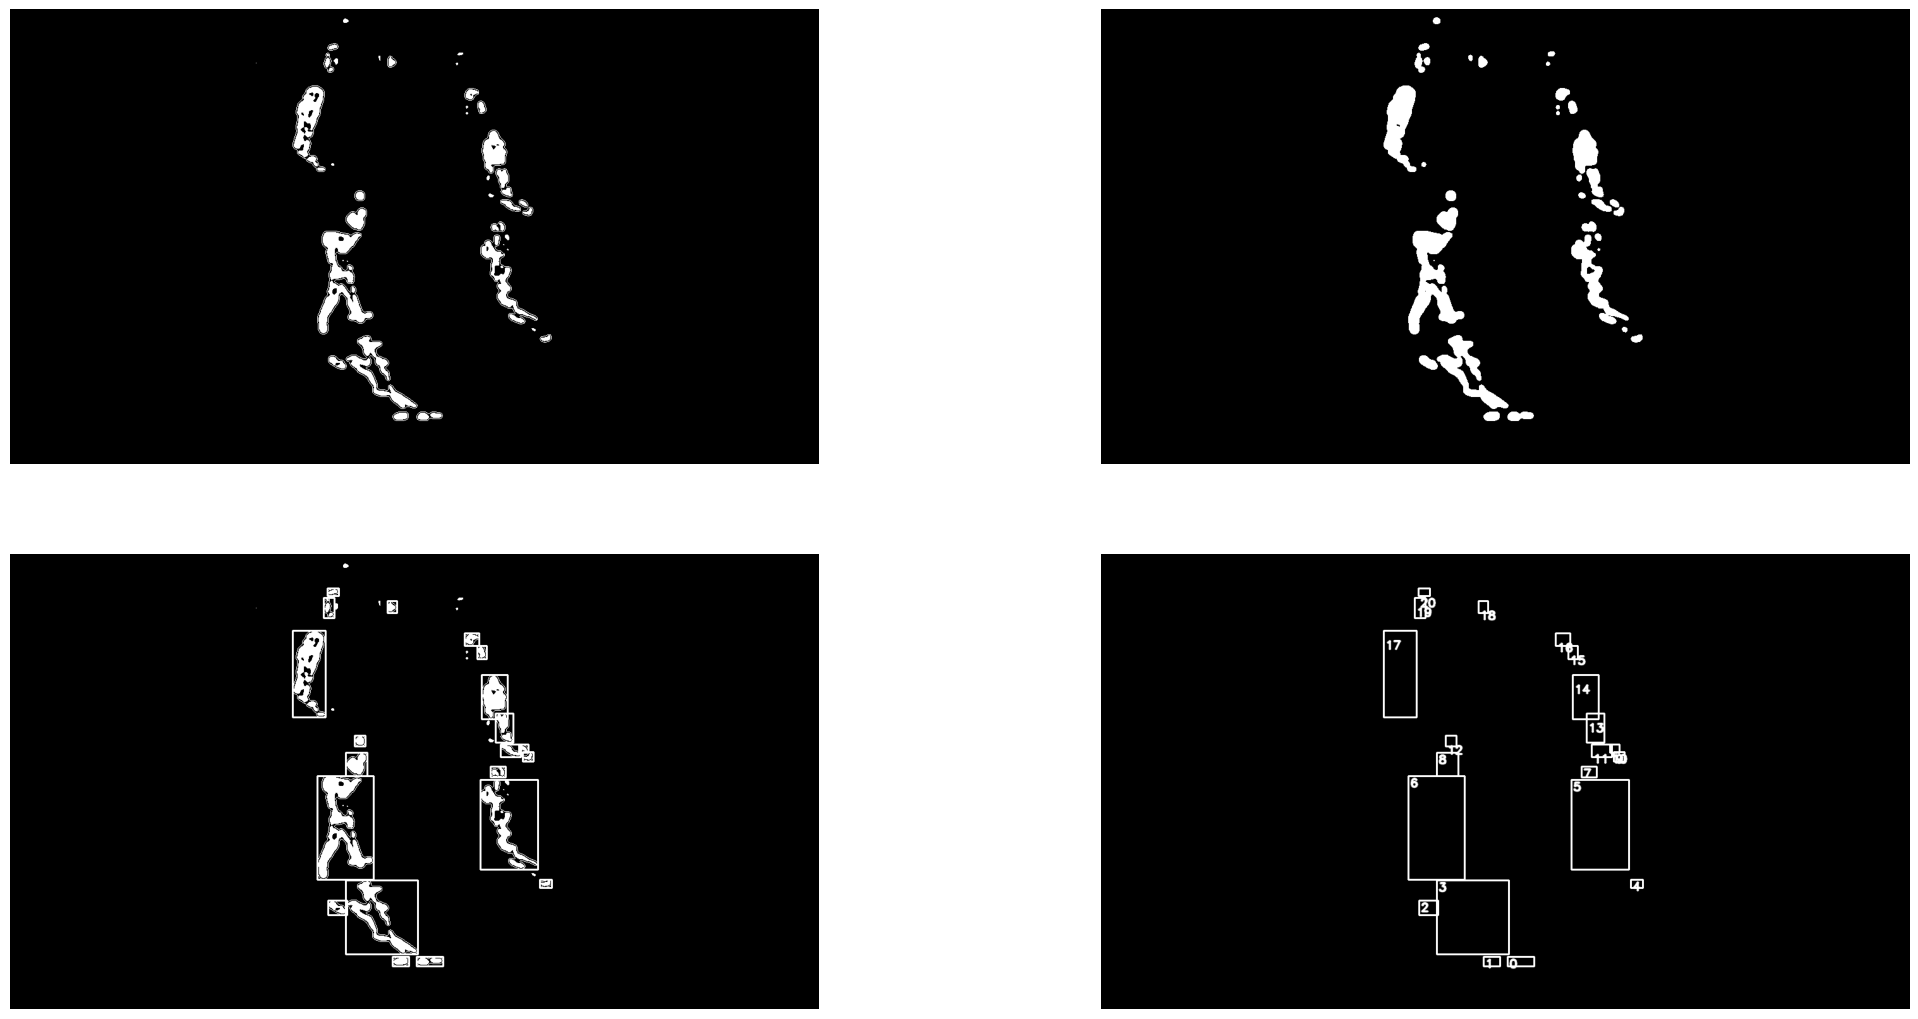

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [158]:
cimg = diff_img_.copy()
cimg_ = cv2.GaussianBlur(cimg, (11, 11), 0)
diff_threshold=30
ret, cimg_ = cv2.threshold(cimg_,diff_threshold,255,cv2.THRESH_BINARY)
#show_img(cimg, cmap='gray')
#show_img(cimg_, cmap='gray')

contours, hierarchy = cv2.findContours(cimg_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)  #cv2.CHAIN_APPROX_SIMPLE
  
print("#contours:", len(contours)) 
WHITE=(255, 255, 255)


#print((x, y, w, h))
print(len(contours))
contours_ = contour_filter(contours, min_area=100)
cv2.drawContours(cimg, contours_, -1, WHITE, 1) 
print(len(contours_))

bbs = contour_boxes(contours_, wh=False)
bimg = cimg.copy()
draw_boxes(bimg, bbs, color=WHITE, thickness=2)
#show_img(bimg, cmap='gray', title='d')

bimg_ = np.zeros(cimg.shape, np.uint8)
draw_boxes(bimg_, bbs, color=WHITE, thickness=2, labels=True)
#show_img(bimg_, cmap='gray', title='e')

show_imgs([cimg,cimg_,bimg,bimg_], titles=None, ncols=2, figsize=(20,10), pad=0)




8
[(486, 314, 685, 652), (838, 515, 857, 528), (744, 191, 835, 499), (545, 287, 562, 304), (719, 125, 754, 166), (447, 121, 499, 258), (597, 74, 612, 93), (496, 54, 520, 101)]


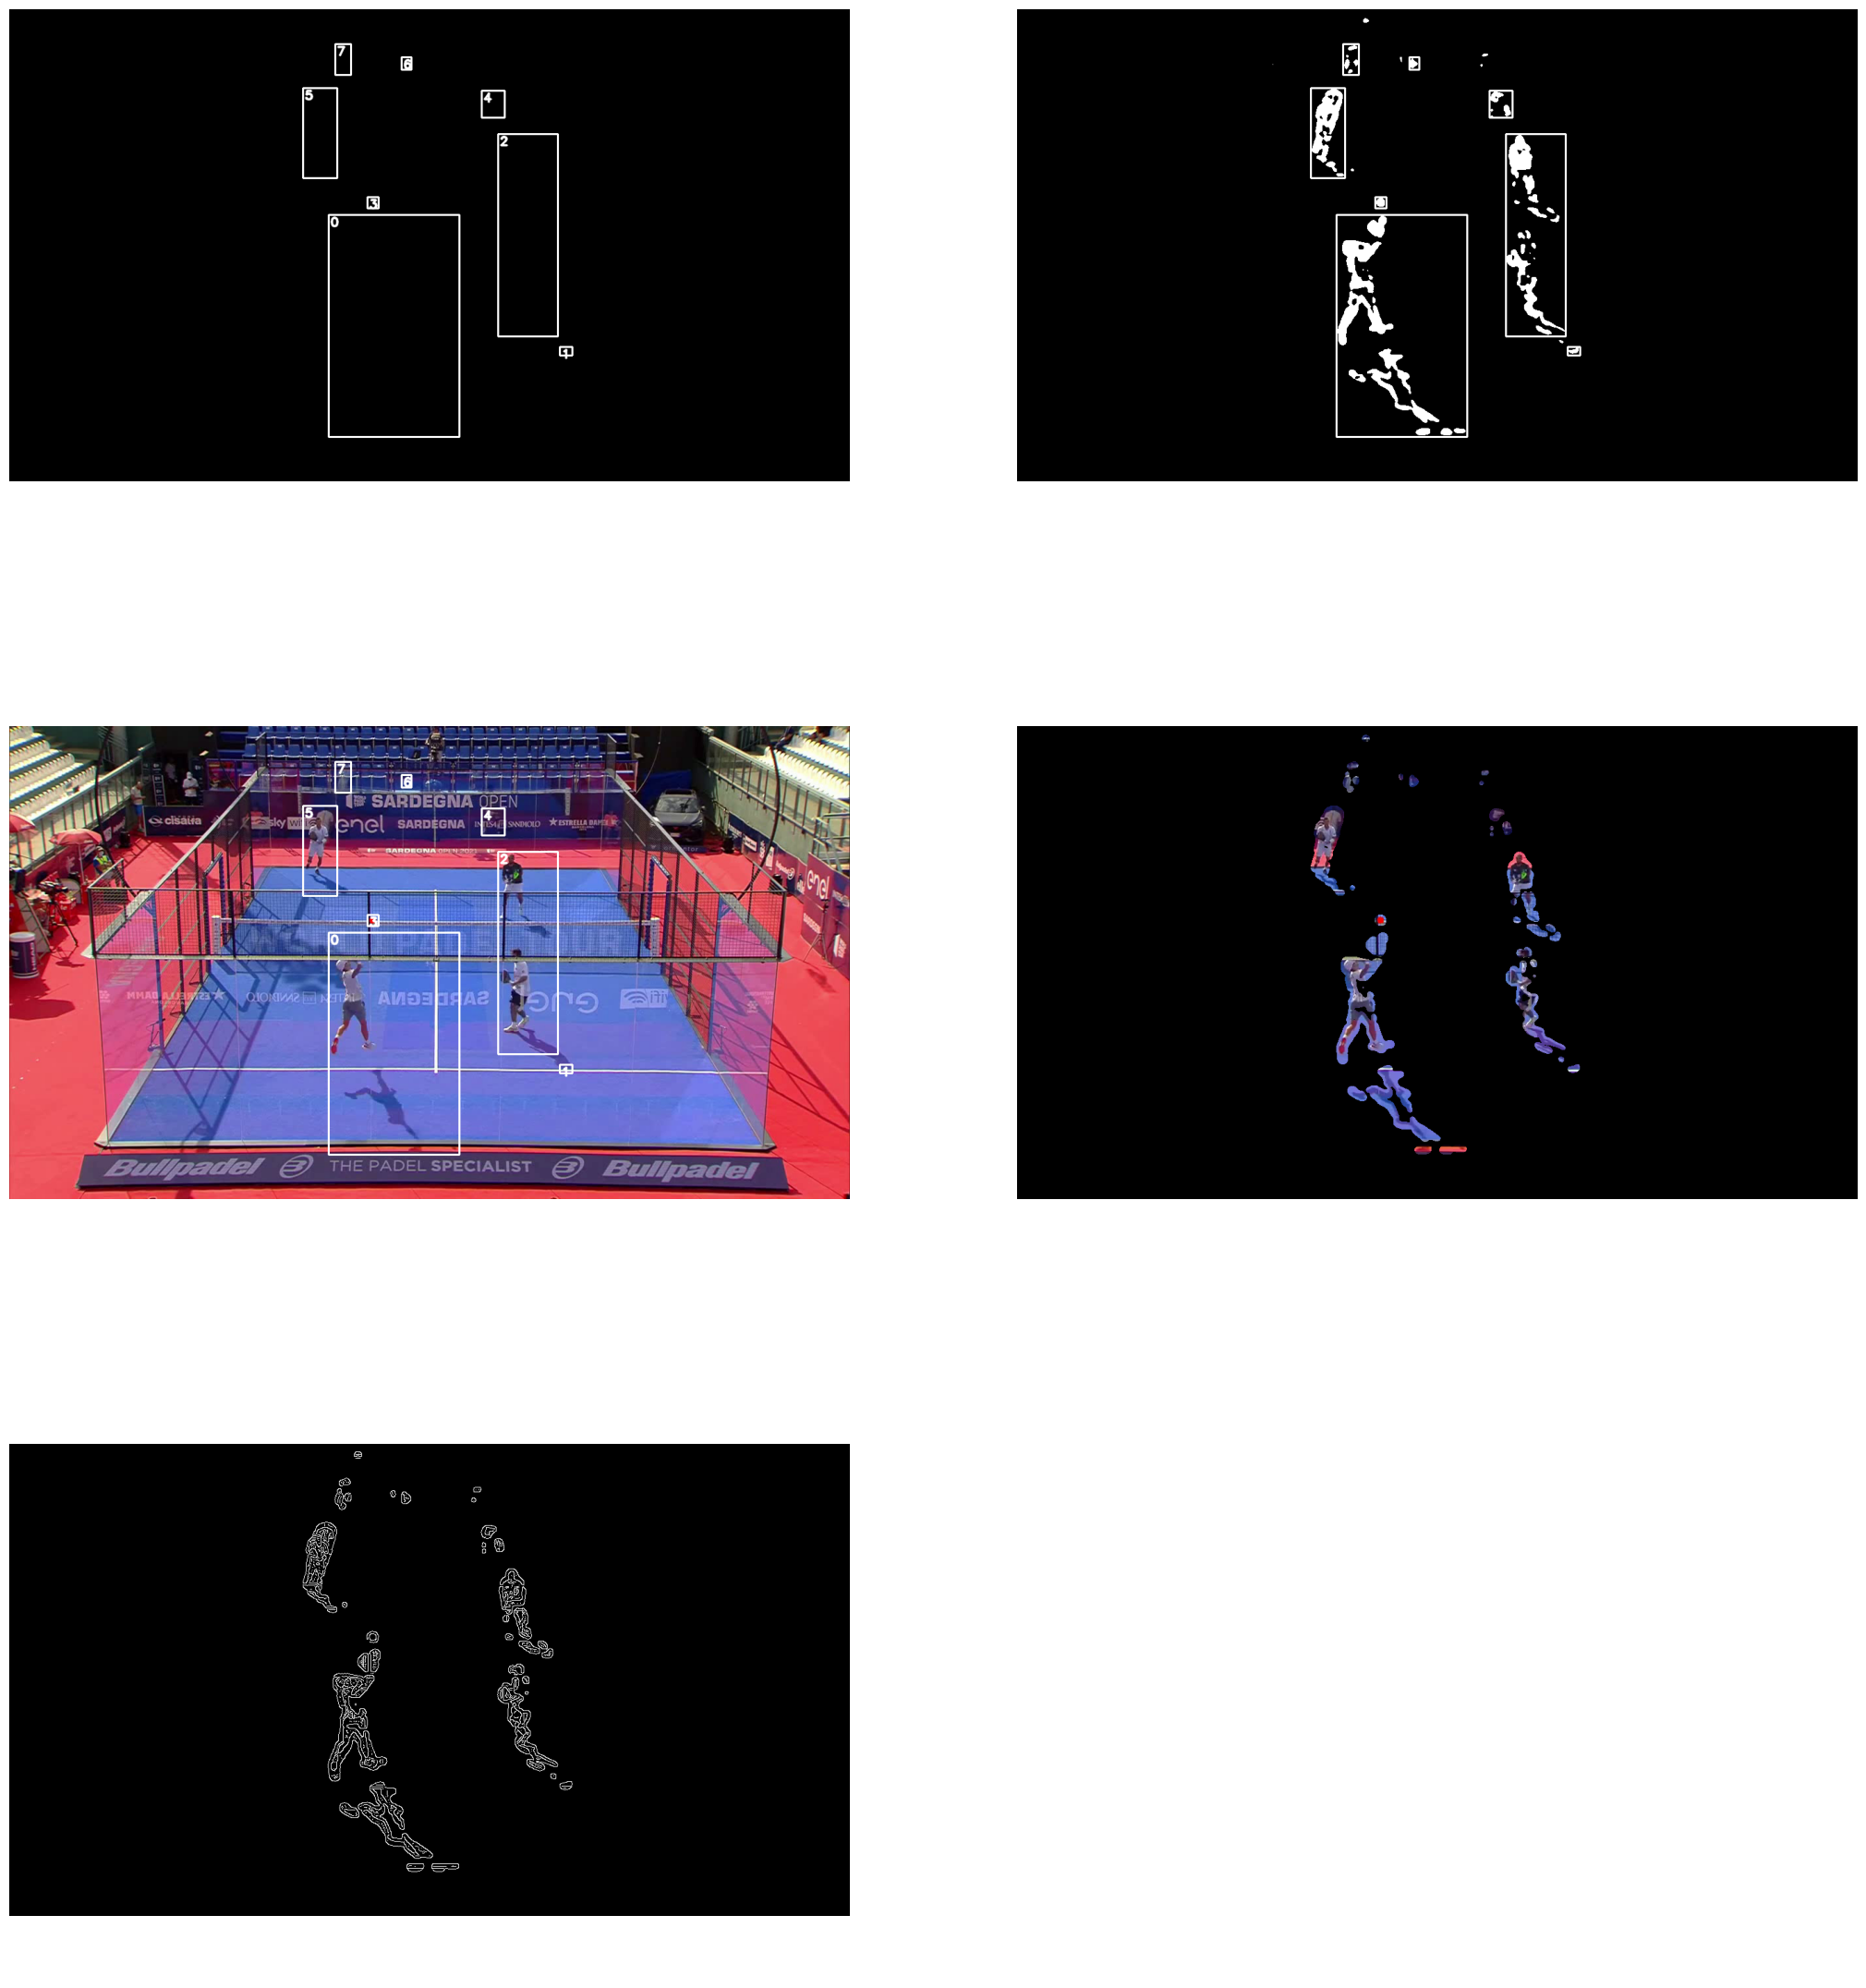

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [382]:
bbs_ = merge_boxes(bbs, max_dist=10)
print(len(bbs_))
mimg = np.zeros(cimg.shape, np.uint8)
draw_boxes(mimg, bbs_, color=WHITE, thickness=2, labels=True)
#show_img(mimg, cmap='gray', title='f')
print(bbs_)

mimg_ = diff_img_.copy()
draw_boxes(mimg_, bbs_, color=WHITE, thickness=2)
#show_img(mimg_, cmap='gray', title='d')

mimg__ = img.copy()
draw_boxes(mimg__, bbs_, color=WHITE, thickness=2, labels=True)
#show_img(mimg__)

masked = cv2.bitwise_and(img,img,mask=cimg_)

emasked = cv2.Canny(masked, 100, 200, apertureSize=5) 

show_imgs([mimg,mimg_,mimg__,masked, emasked], titles=None, ncols=2, bgr=True, figsize=(20,22), pad=0)



{0: (486, 314, 685, 652), 1: (838, 515, 857, 528), 2: (744, 191, 835, 499), 3: (545, 287, 562, 304), 4: (719, 125, 754, 166), 5: (447, 121, 499, 258), 6: (597, 74, 612, 93), 7: (496, 54, 520, 101)}


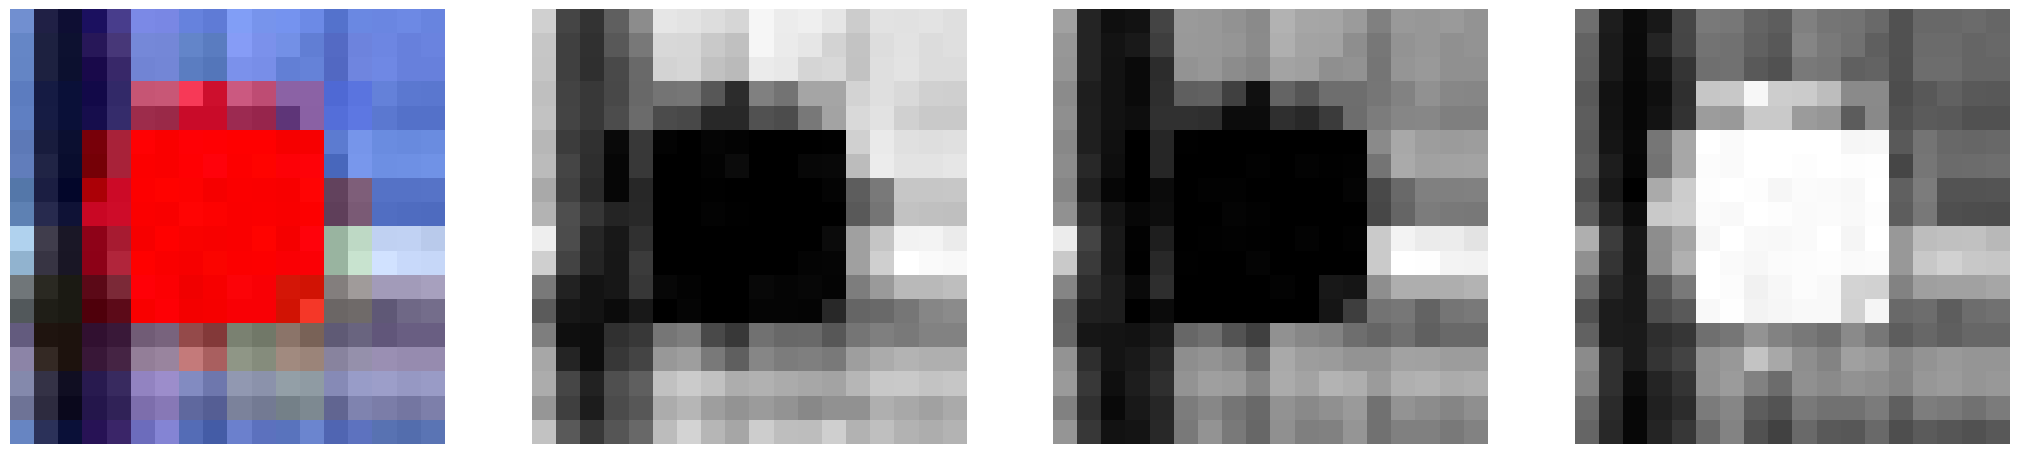

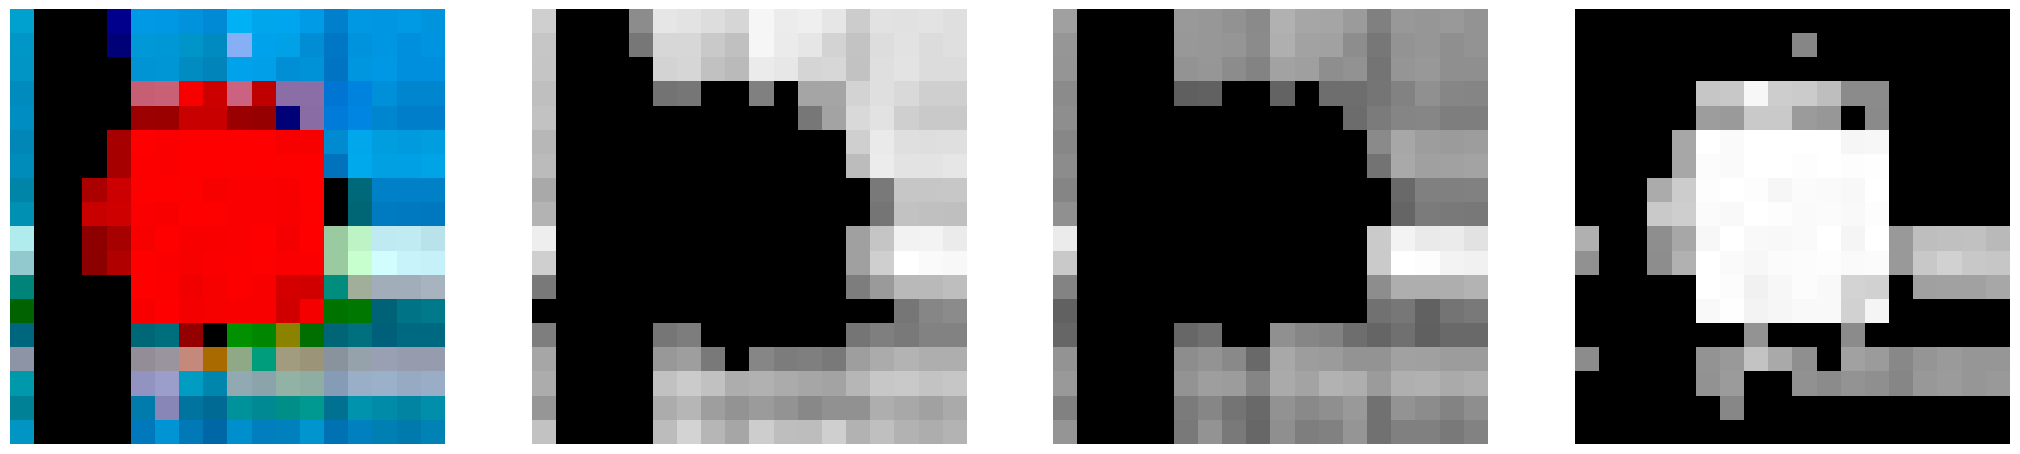

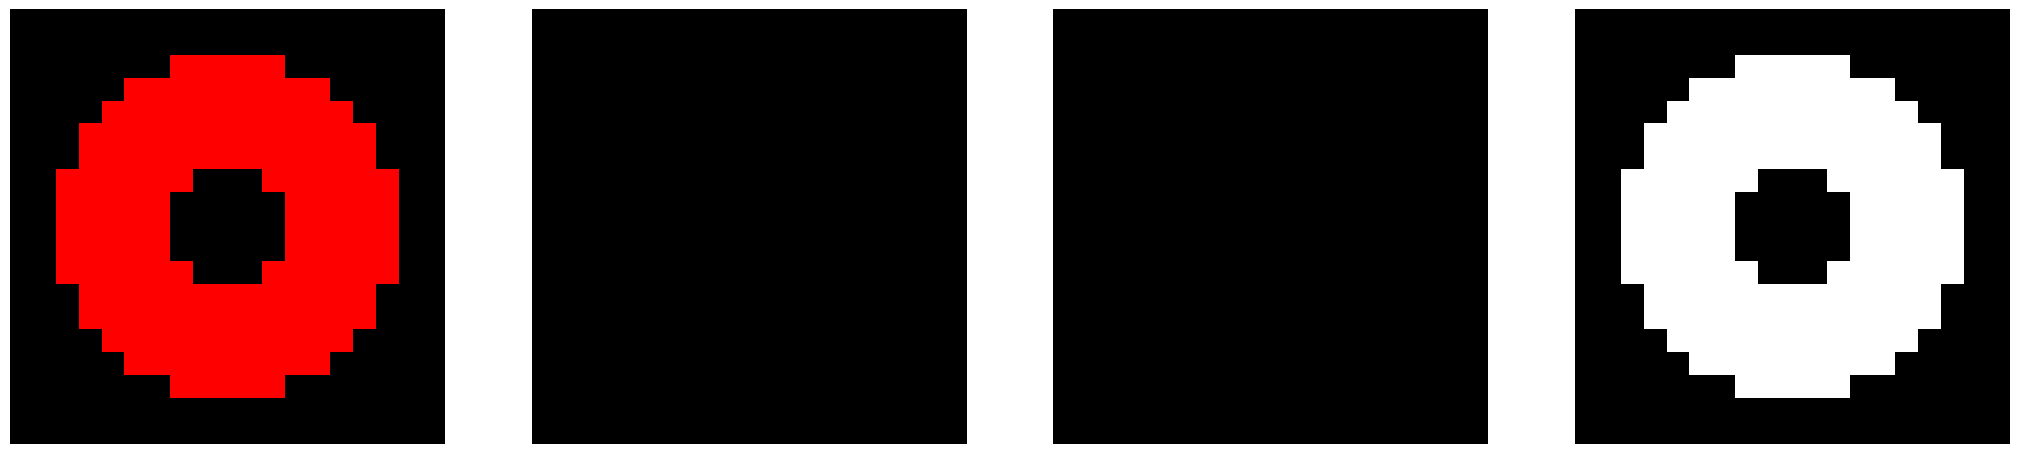

In [375]:
print({i: bbs_[i] for i in range(0, len(bbs_))})
bb = bbs_[3]
ball = img.copy()[bb[1]:bb[3]+1,bb[0]:bb[2]+1,:]
#show_img(ball)


np.set_printoptions(precision=2, suppress=True, linewidth=132)

def normalize(v):
    n = np.linalg.norm(v)
    return v / n if n!=0 else v


def cv_img2float(img):
    return np.float32(img)/255

def cv_kernel2img(kernel):
    k0,k1,k2 = cv2.split(kernel)
    m0,m1,m2 = (np.mean(k0),np.mean(k1),np.mean(k2))
    min0,min1,min2 = (np.min(k0),np.min(k1),np.min(k2))
    k0,k1,k2 = (k0-min0,k1-min1,k2-min2)
    max0,max1,max2 = (np.max(k0),np.max(k1),np.max(k2))
    b0,b1,b2=(255/max0 if max0!=0 else 1,255/max1 if max1!=0 else 1,255/max2 if max2!=0 else 1)
    k0,k1,k2 = (k0*b0,k1*b1,k2*b2)    
    kernel = cv2.merge((k0,k1,k2))
    #print('kernel.2:', kernel[:,:,2])
    kernel = np.uint8(kernel)
    return kernel

def make_ckernel(kernel):
    k = cv_img2float(kernel)
    k0,k1,k2 = cv2.split(kernel) #(kernel[:,:,0],kernel=kernel[:,:,1],kernel=kernel[:,:,2])
    m0,m1,m2 = (np.mean(k0),np.mean(k1),np.mean(k2))
    ret, k0 = cv2.threshold(k0,m0,255,cv2.THRESH_TOZERO)
    ret, k1 = cv2.threshold(k1,m1,255,cv2.THRESH_TOZERO)
    ret, k2 = cv2.threshold(k2,m2,255,cv2.THRESH_TOZERO)
    #k0 = cv.adaptiveThreshold(k0,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,2)
    k0,k1,k2 = (normalize(k0),normalize(k1),normalize(k2))
    m0,m1,m2 = (np.mean(k0),np.mean(k1),np.mean(k2))
    #print(m0,m1,m2)
    k0,k1,k2 = (k0-m0,k1-m1,k2-m2)
    #print('k.0:', k0)
    kernel = cv2.merge((k0,k1,k2))
    return kernel

def make_kernel_o(size=11, nchannels=-1, r=-1, pad=2, thickness=2, color=(1,1,1), bgvalue=-1):
    #kernel = np.zeros((size, size, 1)) 
    shape = (size, size, nchannels) if nchannels>0 else (size, size)
    kernel = np.empty(shape)
    kernel.fill(bgvalue)
    if r<0: r=max(int(size/2)-pad,3)
    cxy = (int(size/2), int(size/2))
    #cv2.circle(kernel, cxy, max(r-1,1), (2,2,2), thickness=-1)
    #print(size, cxy, r, kernel.shape)
    cv2.circle(kernel, cxy, r, color, thickness=thickness)
    return kernel
    
def cv_filter2D(img, kernel, ddepth=-1, anchor=None, delta=None, borderType=None):           
    k = cv_img2float(kernel)
    k0,k1,k2 = cv2.split(kernel) #(kernel[:,:,0],kernel=kernel[:,:,1],kernel=kernel[:,:,2])
    m0,m1,m2 = (np.mean(k0),np.mean(k1),np.mean(k2))
    ret, k0 = cv2.threshold(k0,m0,255,cv2.THRESH_TOZERO)
    ret, k1 = cv2.threshold(k1,m1,255,cv2.THRESH_TOZERO)
    ret, k2 = cv2.threshold(k2,m2,255,cv2.THRESH_TOZERO)
    #k0 = cv.adaptiveThreshold(k0,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,2)
    #k0,k1,k2 = (normalize(k0),normalize(k1),normalize(k2))
    m0,m1,m2 = (np.mean(k0),np.mean(k1),np.mean(k2))
    print(m0,m1,m2)
    k0,k1,k2 = (k0-m0,k1-m1,k2-m2)
    img0,img1,img2 = cv2.split(img) #(img[:,:,0],img[:,:,1],img[:,:,2])
    #print('k.0:', k0)
    #print(k1)
    #print(k2)
    img0 = cv2.filter2D(src=img0, ddepth=ddepth, kernel=k0)
    img1 = cv2.filter2D(src=img1, ddepth=ddepth, kernel=k1)
    img2 = cv2.filter2D(src=img2, ddepth=ddepth, kernel=k2)
    img = cv2.merge((img0,img1,img2))
    return img

def show_channels(img, bgr=True, figsize=(20,10)):
    show_imgs([img,img[:,:,0], img[:,:,1],img[:,:,2]], nrows=1, bgr=bgr, figsize=figsize)

def print_channels(img, name):
    print(f'{name}.0:', img[:,:,0])
    print(f'{name}.1:', img[:,:,1])
    print(f'{name}.2:', img[:,:,2])


kball = make_ckernel(ball)
kball2 = make_kernel_o(19, 3, r=5, thickness=3, color=(-2,-2,1), bgvalue=-2)

#print(kernel_o.shape, ckernel_o.shape)
#print(img.shape, cimg.shape)

#print(kball.shape)
#print_channels(kball_, 'kball_')
#print_channels(kball, 'kball')
#print_channels(cball2, 'cball2')

show_channels(ball)
show_channels(cv_kernel2img(kball))
show_channels(cv_kernel2img(kball2))



0.018838751886023464 0.018432136626523436 0.02048316298095209
0.0 0.0 0.43213296398891965


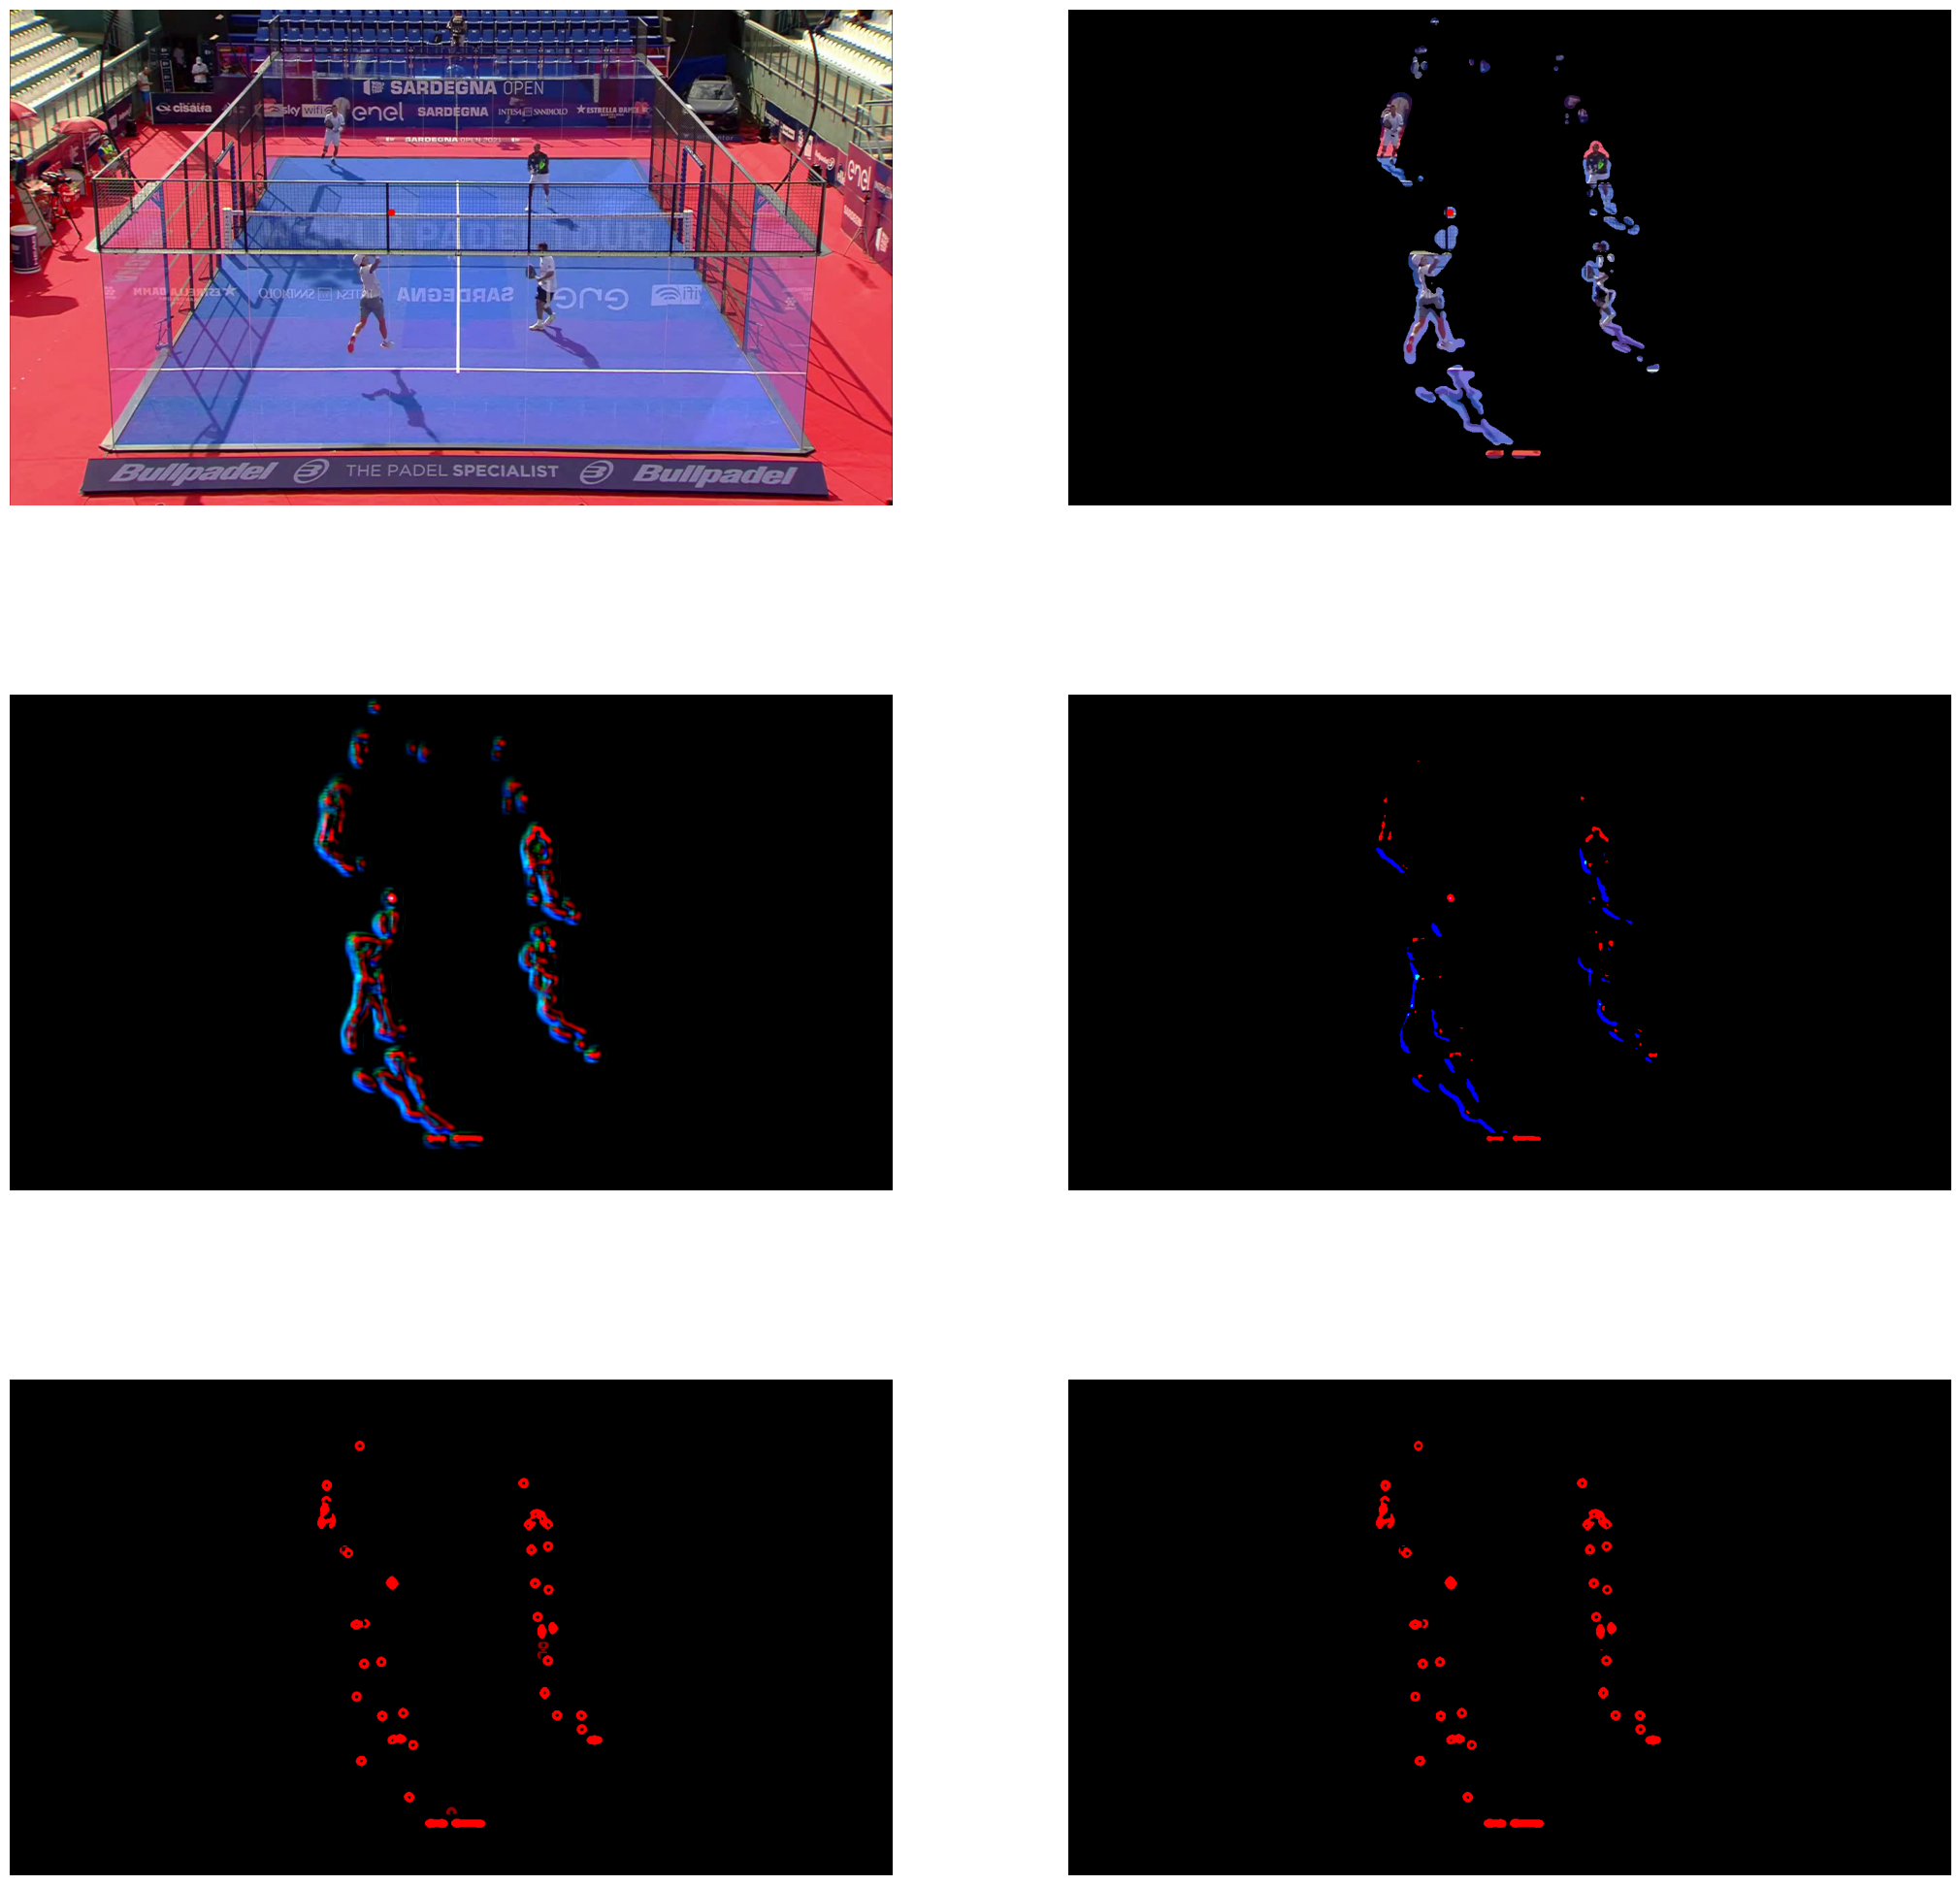

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [376]:

fimg = cv_filter2D(masked,kball)
ret, fimg_ = cv2.threshold(fimg,220,255,cv2.THRESH_BINARY)

fimg2 = cv_filter2D(fimg_,kball2)
ret, fimg2_ = cv2.threshold(fimg2,220,255,cv2.THRESH_BINARY)

show_imgs([img,masked,fimg,fimg_,fimg2,fimg2_], ncols=2, bgr=True, figsize=(20,20))


21 (10, 10) 8 (21, 21)
21 (10, 10) 8 (21, 21, 3)
(21, 21) (21, 21, 3)
(720, 1280, 3) (720, 1280)
ball: (18, 18, 3)


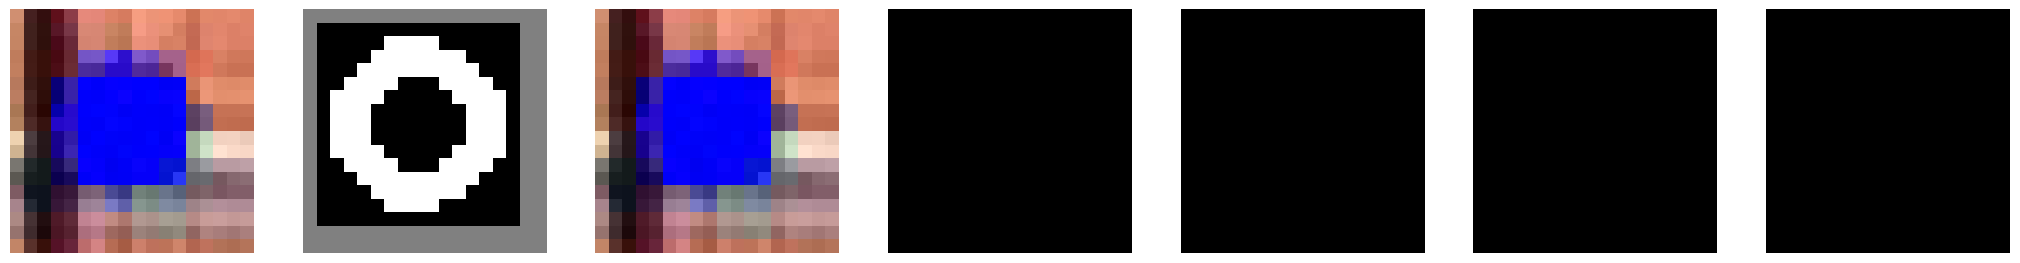

7 (3, 3) 3 (7, 7)
ball: (18, 18, 3) kernel: (7, 7) xy: (5, 5)


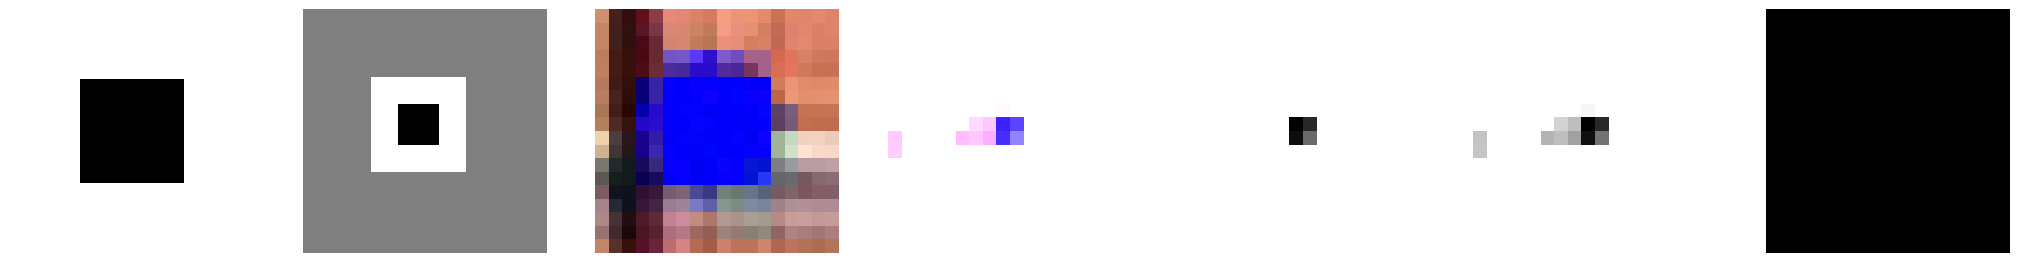

11 (5, 5) 3 (11, 11)
ball: (18, 18, 3) kernel: (11, 11) xy: (3, 3)


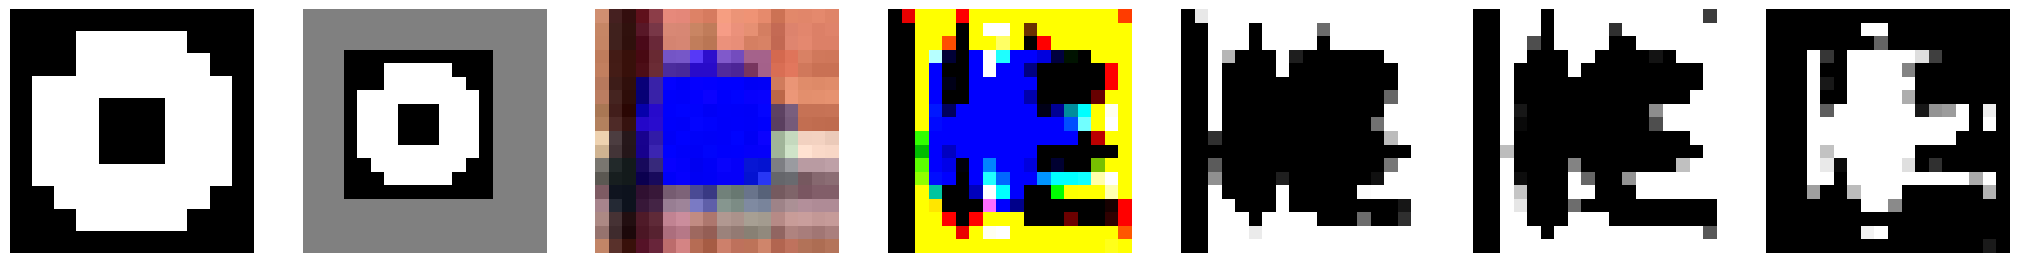

15 (7, 7) 5 (15, 15)
ball: (18, 18, 3) kernel: (15, 15) xy: (1, 1)


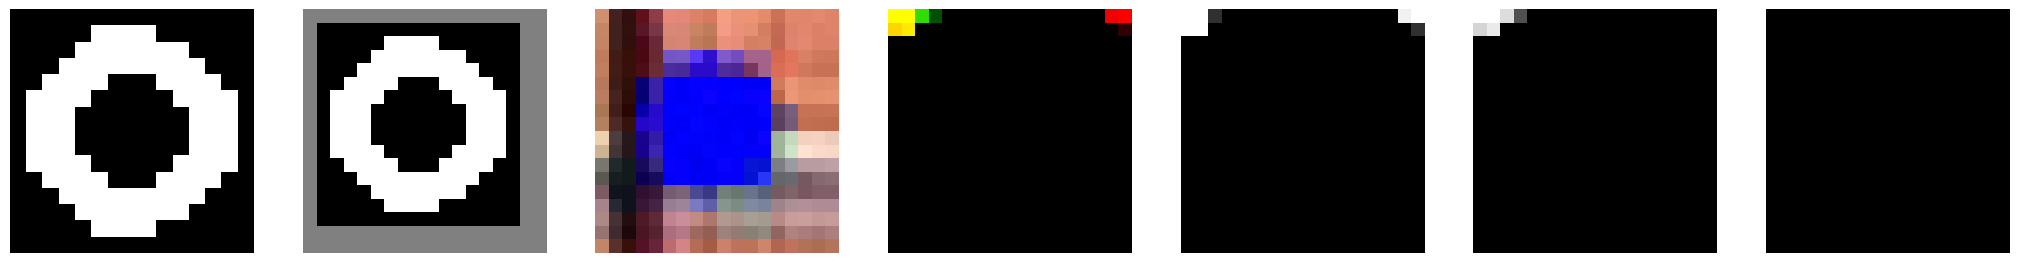

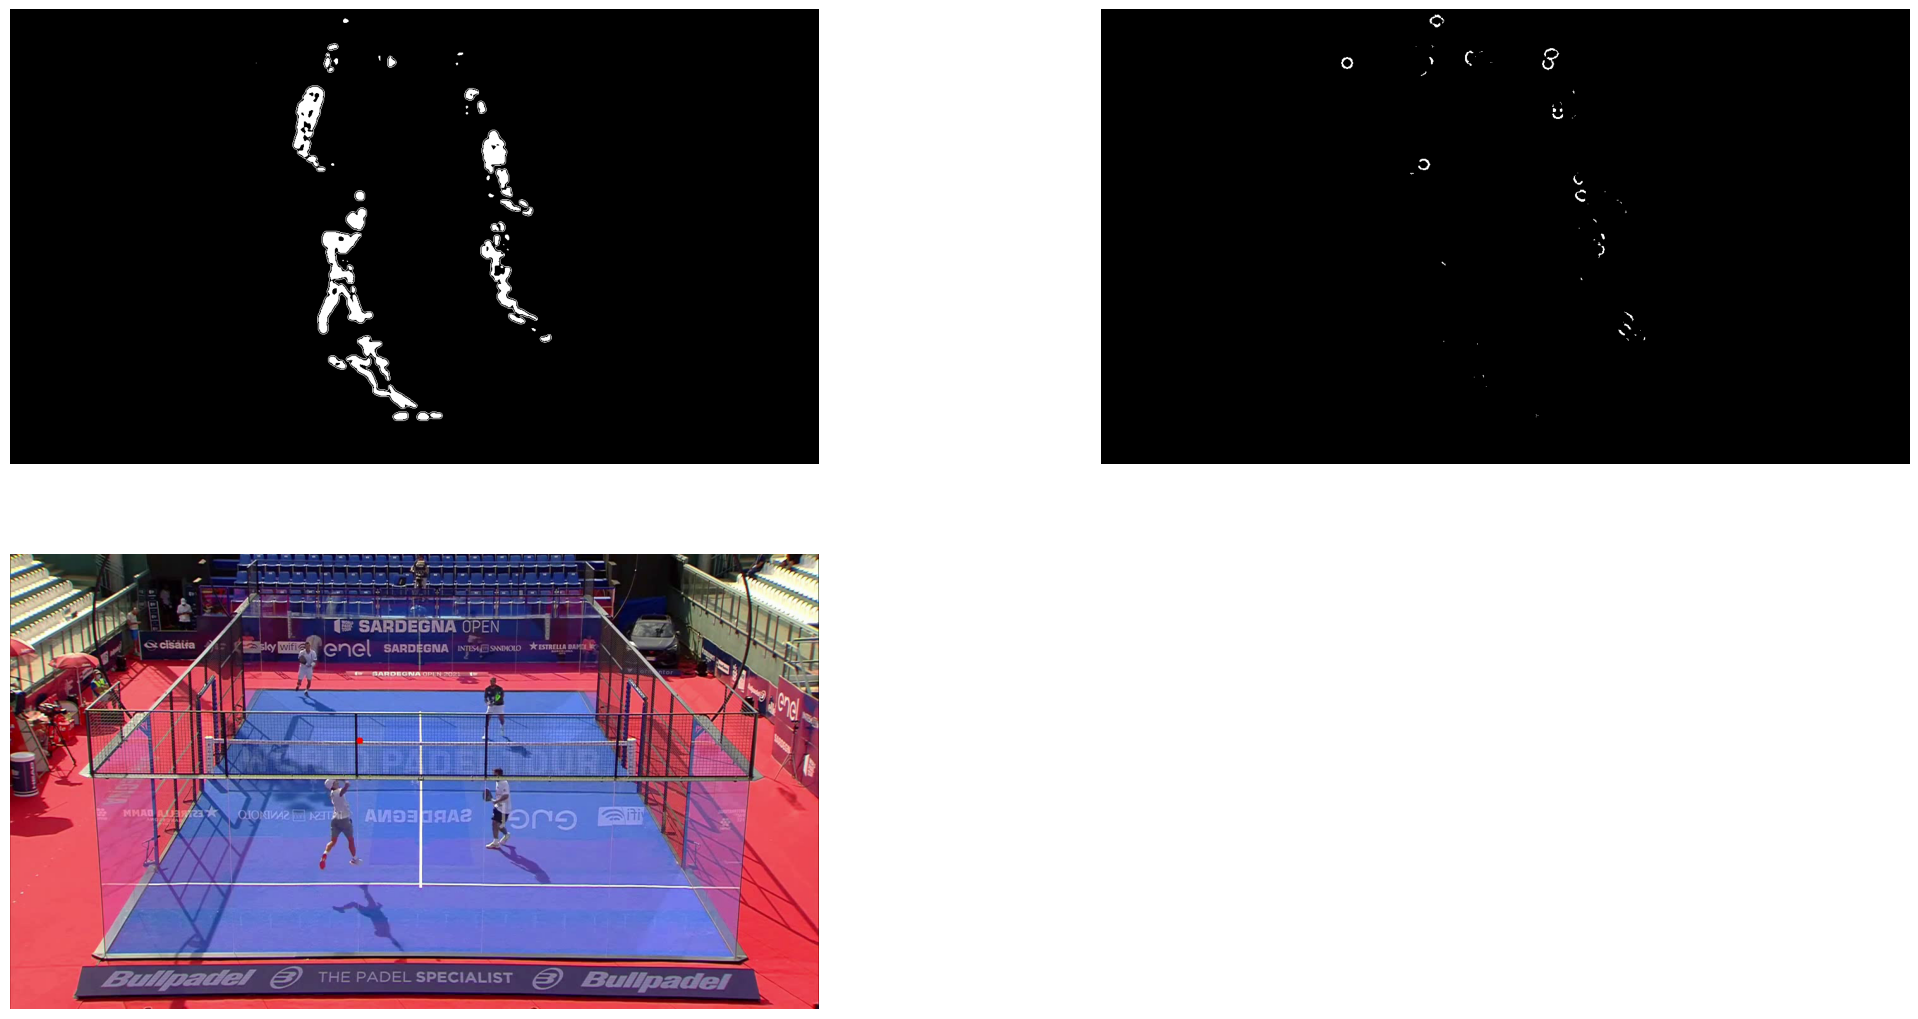

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [314]:
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

print('ball:', ball.shape)
#show_img(kernel_o, cmap='gray')
ball_ = cv2.filter2D(src=ball, ddepth=-1, kernel=kernel_o)
#print(ball_[:,:,0])
#print(ball_[:,:,1])
#print(ball_[:,:,2])

from util.img_util import putImage

show_imgs([ball,kernel_,ball,ball_,ball_[:,:,0],ball_[:,:,1],ball_[:,:,2]], titles=None, nrows=1, title_size=4, figsize=(20,10), pad=0)

for k in [7,11,15]: #,19,21,25
    kernel = make_kernel_o(k)
    ball_ = cv2.filter2D(src=ball, ddepth=-1, kernel=kernel)
    if k<min(ball.shape[0], ball.shape[1]):
        kernel_ = np.zeros((ball.shape[0], ball.shape[1])) 
        xy = (int((ball.shape[1]-kernel.shape[1])/2),int((ball.shape[0]-kernel.shape[0])/2))
        print('ball:', ball.shape, 'kernel:', kernel.shape, 'xy:', xy)        
        putImage(kernel_, kernel, xy[0],xy[1])
    else:
        kernel_ = kernel
    show_imgs([kernel,kernel_,ball,ball_,ball_[:,:,0],ball_[:,:,1],ball_[:,:,2]], titles=None, nrows=1, title_size=4, figsize=(20,10), pad=0)

#print(kernel_o)
#for i in range(0,3): print(ckernel_o[:,:,i])
fcimg = cv2.filter2D(src=img, ddepth=-1, kernel=ball)
fimg = cv2.filter2D(src=cimg, ddepth=-1, kernel=kernel_o)
fcimg_=cv2.cvtColor(fcimg, cv2.COLOR_BGR2RGB)
#show_img(img_)
#show_img(fimg_)
#show_imgs([img,fimg,cimg,fcimg_], ncols=2, nrows=None, title_size=4, figsize=(20,10), pad=0)
show_imgs([cimg,fimg,img_,fcimg_], ncols=2, nrows=None, title_size=4, figsize=(20,10), pad=0)


< cv2.SimpleBlobDetector 00000171B8CFC490>
(< cv2.KeyPoint 00000171C8521450>, < cv2.KeyPoint 00000171C85214B0>, < cv2.KeyPoint 00000171C85213F0>, < cv2.KeyPoint 00000171C85213C0>, < cv2.KeyPoint 00000171C8521360>, < cv2.KeyPoint 00000171C8521480>, < cv2.KeyPoint 00000171C8521300>, < cv2.KeyPoint 00000171C85212D0>, < cv2.KeyPoint 00000171C85212A0>, < cv2.KeyPoint 00000171C8521270>, < cv2.KeyPoint 00000171C8521240>, < cv2.KeyPoint 00000171C8521210>, < cv2.KeyPoint 00000171C85211E0>, < cv2.KeyPoint 00000171C85211B0>, < cv2.KeyPoint 00000171C8521180>, < cv2.KeyPoint 00000171C8521150>, < cv2.KeyPoint 00000171C8521120>, < cv2.KeyPoint 00000171C85210F0>, < cv2.KeyPoint 00000171C85210C0>, < cv2.KeyPoint 00000171C8521090>, < cv2.KeyPoint 00000171C8521060>, < cv2.KeyPoint 00000171C8521030>, < cv2.KeyPoint 00000171C8536030>, < cv2.KeyPoint 00000171C8536060>, < cv2.KeyPoint 00000171C8536090>, < cv2.KeyPoint 00000171C85360C0>, < cv2.KeyPoint 00000171C85360F0>, < cv2.KeyPoint 00000171C8536120>, < cv

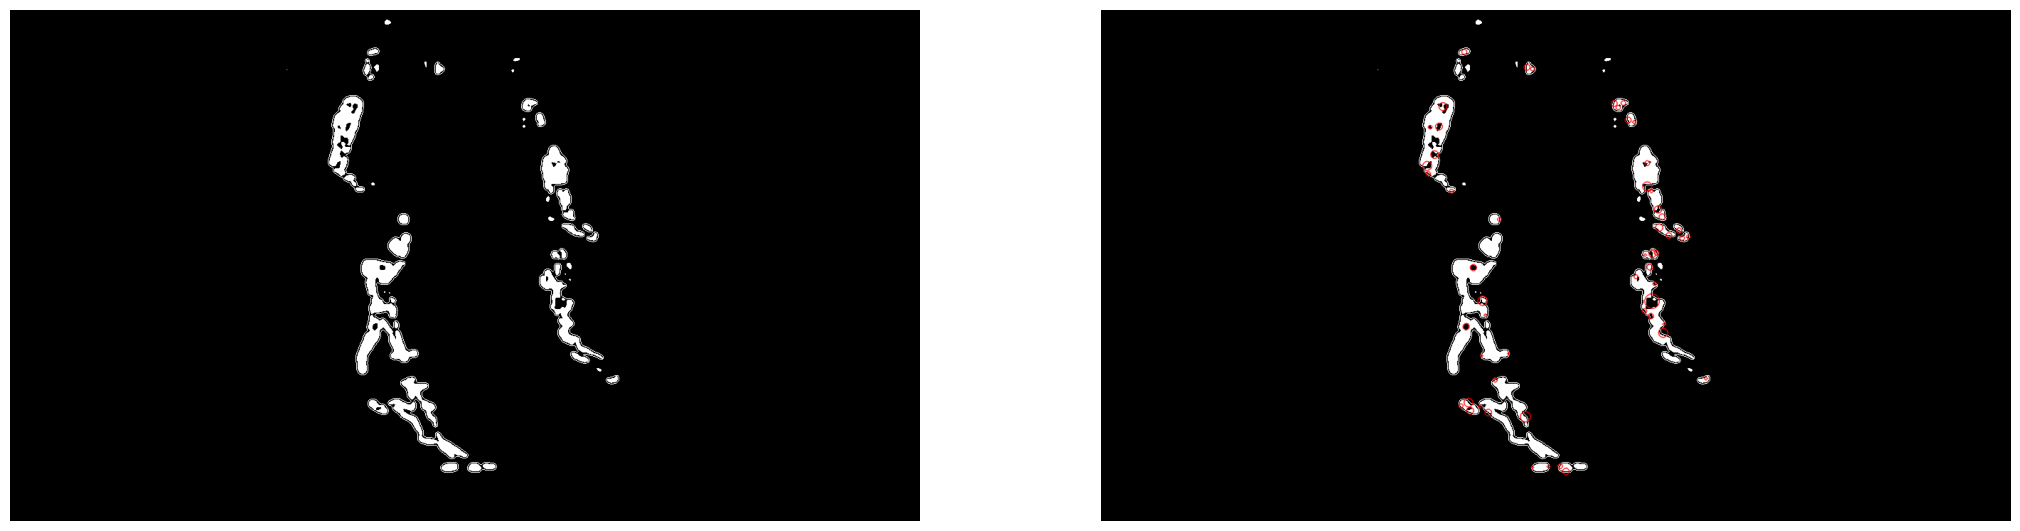

array([<Axes: >, <Axes: >], dtype=object)

In [242]:
# Setup SimpleBlobDetector parameters.
def make_blob_detector(minThreshold = 0, maxThreshold = 200, filterByArea = True, minArea = 10,
        filterByCircularity = True, minCircularity = .2, filterByConvexity = False, minConvexity = 0.87,
        filterByInertia = False, minInertiaRatio = 0.01):
    params = cv2.SimpleBlobDetector_Params() 
    # Change thresholds
    params.minThreshold = minThreshold
    params.maxThreshold = maxThreshold;
    # Filter by Area.
    params.filterByArea = filterByArea
    params.minArea = minArea
    # Filter by Circularity
    params.filterByCircularity = filterByCircularity
    params.minCircularity = minCircularity
     
    # Filter by Convexity
    params.filterByConvexity = filterByConvexity
    params.minConvexity = minConvexity
     
    # Filter by Inertia
    params.filterByInertia = filterByInertia
    params.minInertiaRatio = minInertiaRatio
     
    # Create a detector with the parameters
    ver = (cv2.__version__).split('.')
    if int(ver[0]) < 3 :
        detector = cv2.SimpleBlobDetector(params)
    else : 
        detector = cv2.SimpleBlobDetector_create(params)
    return detector

detector = make_blob_detector()
print(detector)

blobs = detector.detect(cimg)
print(blobs)
blobs_cimg = cv2.drawKeypoints(cimg, blobs, np.array([]), (255,0,0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(cimg.shape, blobs_cimg.shape)
show_imgs([cimg,blobs_cimg], ncols=2, figsize=(20,10), pad=0)


['4', '11', '0']

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches

for image_idx in range(len(best_results_per_input)):
    fig, ax = plt.subplots(1)
    # Show original, denormalized image...
    image = inputs[image_idx] / 2 + 0.5
    ax.imshow(image)
    # ...with detections
    bboxes, classes, confidences = best_results_per_input[image_idx]
    for idx in range(len(bboxes)):
        left, bot, right, top = bboxes[idx]
        x, y, w, h = [val * 300 for val in [left, bot, right - left, top - bot]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, "{} {:.0f}%".format(classes_to_labels[classes[idx] - 1], confidences[idx]*100), bbox=dict(facecolor='white', alpha=0.5))
plt.show()


In [139]:
from transformers import AutoModelForObjectDetection
MODEL_NAME = "microsoft/conditional-detr-resnet-50"  # or "facebook/detr-resnet-50"
IMAGE_SIZE = 480

model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    #id2label=id2label,
    #label2id=label2id,
    ignore_mismatched_sizes=True,
)

ModuleNotFoundError: No module named 'transformers'